In [1]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [2]:
# 1. Load Data
# -----------------------------
train_path = "/content/Train_Data.xlsx"
test_path = "/content/Test_Data.xlsx"
extracted_path ="/content/extracted_data.xlsx"

train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)
extracted_df = pd.read_excel(extracted_path)


In [3]:
# Feature & targets
vs_col = "VS" if "VS" in train_df.columns else "Vs"
y_cols = ["Ns","Nm","NL"]

X_train = train_df[[vs_col]].values
y_train = train_df[y_cols].values
X_test = test_df[[vs_col]].values


In [4]:
# 2. Define Best Models
# -----------------------------
model_ns = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)   # Best for Ns
model_nm = GradientBoostingRegressor(random_state=42)         # Best for Nm
model_nl = KNeighborsRegressor(n_neighbors=5)                 # Best for NL


In [5]:
# 3. Train Models
model_ns.fit(X_train, y_train[:,0])


SVR(C=100, gamma=0.1)

In [6]:
model_nm.fit(X_train, y_train[:,1])



GradientBoostingRegressor(random_state=42)

In [7]:

model_nl.fit(X_train, y_train[:,2])


KNeighborsRegressor()

In [8]:
# 4. Predict on Test Data
# -----------------------------
pred_ns = model_ns.predict(X_test)
pred_nm = model_nm.predict(X_test)
pred_nl = model_nl.predict(X_test)

# Combine predictions
pred_all = np.vstack([pred_ns, pred_nm, pred_nl]).T

In [9]:
# 5. Evaluate Against Experimental Data
# -----------------------------
def evaluate(actual, pred, label):
    rmse_val = np.sqrt(mean_squared_error(actual, pred))
    mae_val = mean_absolute_error(actual, pred)
    mape_val = np.mean(np.abs((actual - pred) / actual)) * 100
    se_val = np.std(actual - pred, ddof=1) / np.sqrt(len(actual))
    return [label, rmse_val, mae_val, mape_val, se_val]

metrics = []
if len(pred_all) == len(extracted_df):
    actual = extracted_df[y_cols].values
    metrics.append(evaluate(actual[:,0], pred_all[:,0], "Ns"))
    metrics.append(evaluate(actual[:,1], pred_all[:,1], "Nm"))
    metrics.append(evaluate(actual[:,2], pred_all[:,2], "NL"))

results_df = pd.DataFrame(metrics, columns=["Variable","RMSE","MAE","MAPE(%)","StdErr(residuals)"])


In [10]:
# 6. Print Results
# -----------------------------
print("Evaluation of Best Models per Variable:")
print(results_df)

Evaluation of Best Models per Variable:
  Variable       RMSE        MAE     MAPE(%)  StdErr(residuals)
0       Ns  28.176389  27.755728  306.132345           0.666283
1       Nm  18.828725  13.276960   28.374522           2.411174
2       NL   4.886679   3.796296   41.728020           0.666283


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

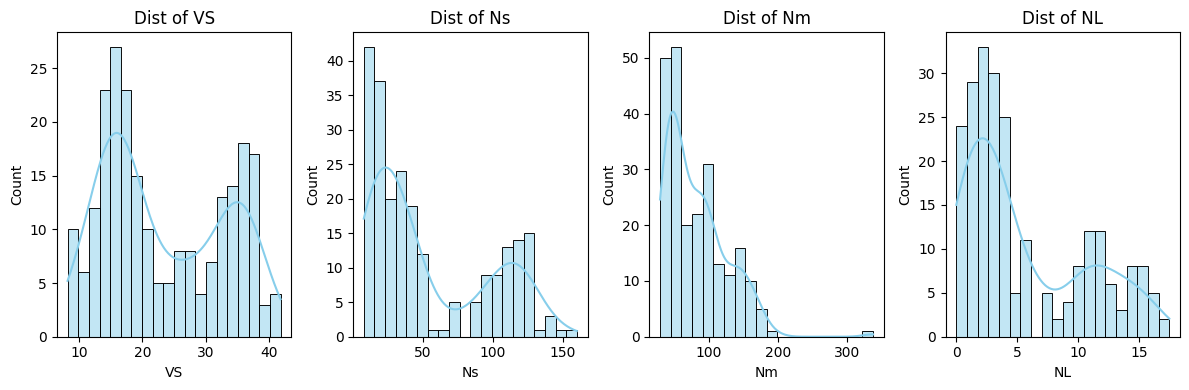

In [12]:
# EDA
plt.figure(figsize=(12,4))
for i, col in enumerate([vs_col]+y_cols):
    plt.subplot(1,4,i+1)
    sns.histplot(train_df[col], kde=True, bins=20, color="skyblue")
    plt.title(f"Dist of {col}")
plt.tight_layout()
plt.show()

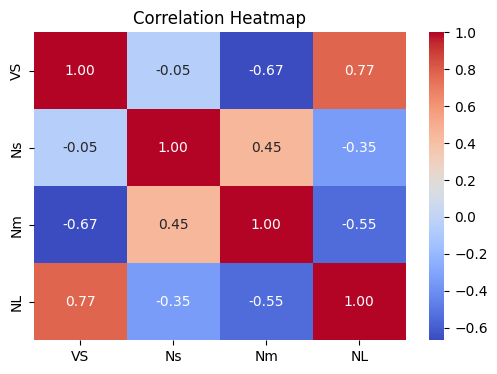

In [13]:
# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(train_df[[vs_col]+y_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


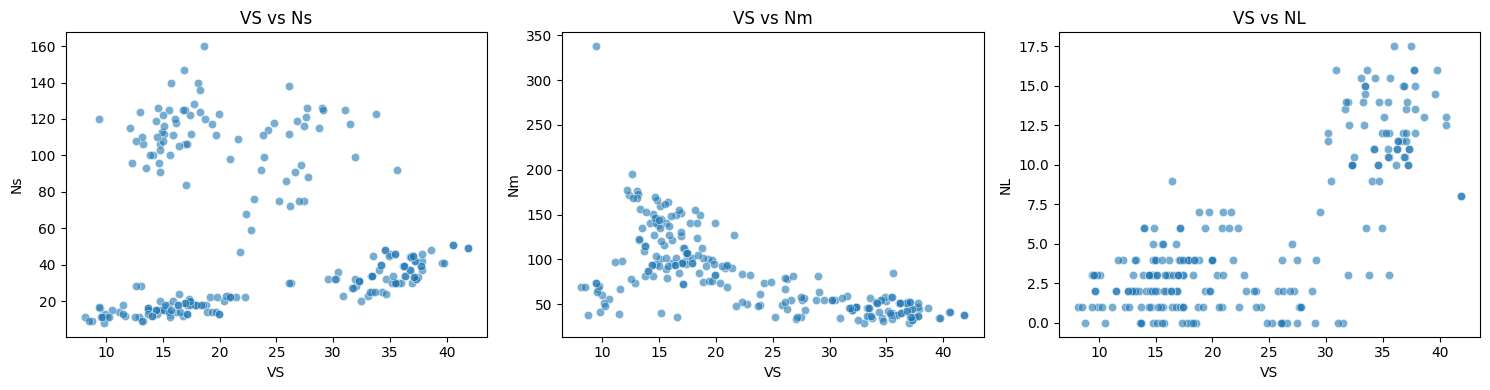

In [14]:
# Scatter plots VS vs Ns/Nm/NL
plt.figure(figsize=(15,4))
for i, col in enumerate(y_cols):
    plt.subplot(1,3,i+1)
    sns.scatterplot(x=train_df[vs_col], y=train_df[col], alpha=0.6)
    plt.title(f"{vs_col} vs {col}")
plt.tight_layout()
plt.show()


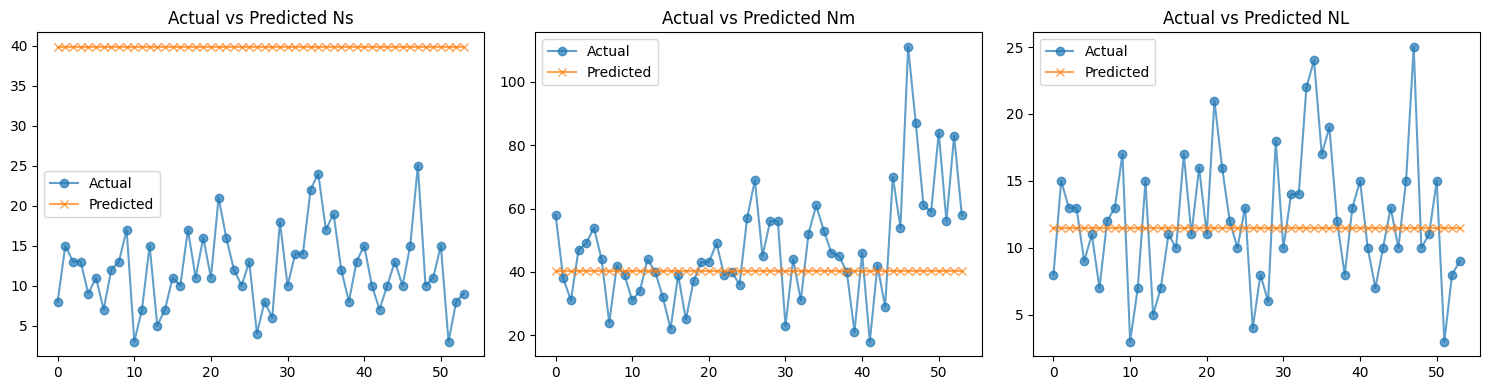

In [15]:
# Prediction Plots
actual = extracted_df[y_cols].values

# Line plots: Actual vs Predicted
plt.figure(figsize=(15,4))
for i, col in enumerate(y_cols):
    plt.subplot(1,3,i+1)
    plt.plot(actual[:,i], label="Actual", marker='o', alpha=0.7)
    plt.plot(pred_all[:,i], label="Predicted", marker='x', alpha=0.7)
    plt.title(f"Actual vs Predicted {col}")
    plt.legend()
plt.tight_layout()
plt.show()

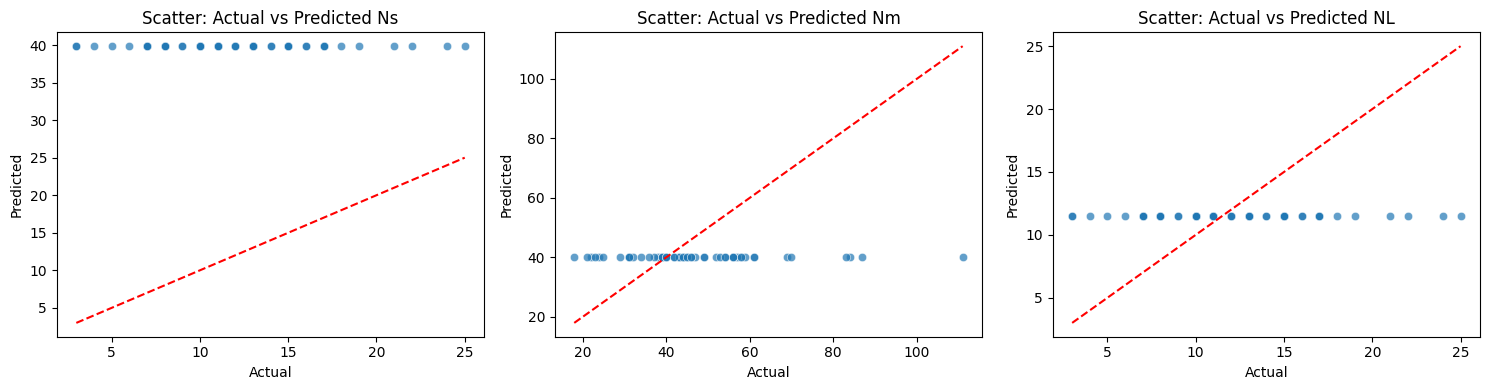

In [16]:
# Scatterplots: Actual vs Predicted
plt.figure(figsize=(15,4))
for i, col in enumerate(y_cols):
    plt.subplot(1,3,i+1)
    sns.scatterplot(x=actual[:,i], y=pred_all[:,i], alpha=0.7)
    plt.plot([actual[:,i].min(), actual[:,i].max()],
             [actual[:,i].min(), actual[:,i].max()],
             'r--')  # y=x line
    plt.title(f"Scatter: Actual vs Predicted {col}")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
plt.tight_layout()
plt.show()